<a href="https://colab.research.google.com/github/bhoomikaiyer540-hash/arugithub/blob/main/Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

As this is labelled data using linear regression algorithm to predict the employee productivity scores

In [ ]:
import pandas as pd
import io
data = [
  [2,40,38,3,62],
  [5,60,42,6,78],
  [1,20,35,2,55],
  [8,80,45,8,88],
  [4,50,40,5,72],
  [10,90,48,9,92],

  [3,30,37,4,65],
  [6,70,44,7,82],
  [7,75,46,7,85],
  [2,25,36,3,60]
]

column_names = ['Experience','Training Hours','Working Hours','Projects','Productivity Score']

df = pd.DataFrame(data, columns=column_names)


# Clean column names
df.columns = df.columns.str.replace(' ', '_').str.replace('(yrs)', '', regex=False).str.strip()

print("Dataset loaded successfully:")
print(df)




   Experience  Training Hours  Working Hours  Projects  Productivity Score
0           2              40             38         3                  62
1           5              60             42         6                  78
2           1              20             35         2                  55
3           8              80             45         8                  88
4           4              50             40         5                  72
5          10              90             48         9                  92
6           3              30             37         4                  65
7           6              70             44         7                  82
8           7              75             46         7                  85
9           2              25             36         3                  60
Dataset loaded successfully:
   Experience  Training_Hours  Working_Hours  Projects  Productivity_Score
0           2              40             38         3                 

In [ ]:
X = df[['Experience', 'Training_Hours', 'Working_Hours', 'Projects']]
y = df['Productivity_Score']

In [ ]:
#find correlation
df.corr()

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score
Experience,1.000000,0.969810,0.973178,0.988194,0.981991
Training_Hours,0.969810,1.000000,0.993132,0.977151,0.987045
Working_Hours,0.973178,0.993132,1.000000,0.974701,0.985684
Projects,0.988194,0.977151,0.974701,1.000000,0.995696
Productivity_Score,0.981991,0.987045,0.985684,0.995696,1.000000


In [ ]:

#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#Scale all values in the columns:
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.00514142, -0.59750544, -0.71706255, -1.06904497],
       [ 0.07179582,  0.25607376,  0.20817945,  0.26726124],
       [-1.3641205 , -1.45108464, -1.41099406, -1.51448037],
       [ 1.14873305,  1.10965296,  0.90211095,  1.15813205],
       [-0.28718326, -0.17071584, -0.25444155, -0.17817416],
       [ 1.86669121,  1.53644256,  1.59604246,  1.60356745],
       [-0.64616234, -1.02429504, -0.94837305, -0.62360956],
       [ 0.4307749 ,  0.68286336,  0.67080045,  0.71269665],
       [ 0.78975397,  0.89625816,  1.13342146,  0.71269665],
       [-1.00514142, -1.23768984, -1.17968356, -1.06904497]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


### Model Coefficients

Let's examine the coefficients of the trained model. These values represent the change in 'Productivity Score' for a one-unit increase in the corresponding feature, holding all other features constant.

In [ ]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

display(coefficients)

,Feature,Coefficient,Absolute_Coefficient
3,Projects,4.885986,4.885986
2,Working_Hours,-1.085511,1.085511
1,Training_Hours,0.272684,0.272684
0,Experience,-0.263658,0.263658


Interpretaions:
1. Which factor most strongly impacts productivity?

based on the results of cofficient, Projects is the factor that most strongly impacts productivity.

In [ ]:
display(coefficients)

most_impactful_feature = coefficients.iloc[0]['Feature']
print(f"The factor that most strongly impacts productivity is: {most_impactful_feature}")

,Feature,Coefficient,Absolute_Coefficient
3,Projects,4.885986,4.885986
2,Working_Hours,-1.085511,1.085511
1,Training_Hours,0.272684,0.272684
0,Experience,-0.263658,0.263658


The factor that most strongly impacts productivity is: Projects


2. How does training affect productivity

The coeffiecent for training hours is +ve values. if the training hours increaes so does the productivity score we can infer

3. Should the company increase training hours or working hours?

We can see that training hours is +ve values 0.27 and working hours is -ve value -1.085, this clear indicates training will help company productivity score

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the mean of other features (excluding Working_Hours, which we will vary)
mean_experience = df['Experience_'].mean()
mean_training_hours = df['Training_Hours'].mean()
mean_projects = df['Projects'].mean()

# Define a range of working hours to explore
min_working_hours = df['Working_Hours'].min()
max_working_hours = df['Working_Hours'].max()
working_hours_range = np.linspace(min_working_hours - 5, max_working_hours + 5, 50) # Extend range slightly for visualization

# Create a DataFrame for predictions
# Each row will have mean values for other features and a different working hour value
prediction_df = pd.DataFrame({
    'Experience_': [mean_experience] * len(working_hours_range),
    'Training_Hours': [mean_training_hours] * len(working_hours_range),
    'Working_Hours': working_hours_range,
    'Projects': [mean_projects] * len(working_hours_range)
})

# Predict productivity scores using the trained model
predicted_productivity = model.predict(prediction_df)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(working_hours_range, predicted_productivity, marker='o', linestyle='-', color='blue')
plt.title('Predicted Productivity Score vs. Working Hours (Other Factors Constant)')
plt.xlabel('Working Hours')
plt.ylabel('Predicted Productivity Score')
plt.grid(True)
plt.show()

print("As the plot shows, according to the current linear regression model, an increase in working hours is associated with a decrease in productivity score.")
print("This implies that within the bounds of this linear model, the 'optimal' limit for working hours to maximize productivity would be the lowest possible working hours observed or extrapolated.")
print("It's important to note that a purely linear model might not fully capture the complex relationship between working hours and productivity, which often involves a peak followed by a decline (a non-linear relationship). To model such a relationship, a different type of regression (e.g., polynomial regression) might be more appropriate.")

KeyError: 'Experience_'

### Documentation and Interpretation

The plot you just saw visually represents the model's prediction for productivity across a range of working hours, keeping other factors (Experience, Training Hours, Projects) constant at their average values.

**Key takeaway from the plot:**
*   Given the current linear regression model, an increase in 'Working Hours' is associated with a decrease in the 'Productivity Score'. This means, according to this specific model, that the 'optimal' working hours for maximizing productivity would be the lowest values within the observed range.

**Important Considerations:**
*   **Linearity Assumption:** This conclusion is based on a linear model. In reality, the relationship between working hours and productivity is often non-linear, where productivity might increase up to a certain point and then decrease due to factors like burnout or fatigue. A more complex model (e.g., polynomial regression, or other non-linear models) might capture this nuanced relationship better.
*   **Causation vs. Correlation:** The model shows a correlation, but it does not definitively prove causation. Other unmeasured factors could be influencing both working hours and productivity.
*   **Data Range:** The predictions are most reliable within the range of the data used for training the model. Extrapolating far beyond this range might lead to inaccurate conclusions.

4. What happens if Working Hours increase beyond optimal limits?

WE can clealy make out that if the working hours increasese the productivity reduces also negative coeffieicent for working hours -1.085511 indicates this,

5. Can productivity ever decrease with more experience?
from the provided data set we can make that coeffiecient is -ve indicating the predicted productvity decreased with more experience

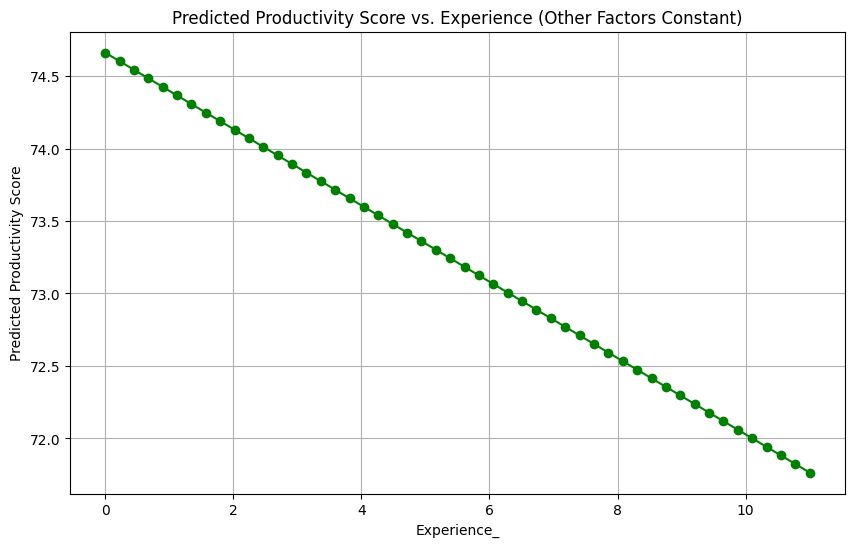

As the plot shows, according to the current linear regression model, an increase in experience is associated with a decrease in productivity score. This is consistent with the negative coefficient for 'Experience_'.
However, as noted before, linear models may not capture the full complexity of real-world relationships, and other factors or non-linear effects might be at play.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the mean of other features (excluding Experience_, which we will vary)
mean_training_hours = df['Training_Hours'].mean()
mean_working_hours = df['Working_Hours'].mean()
mean_projects = df['Projects'].mean()

# Define a range of experience to explore
min_experience = df['Experience_'].min()
max_experience = df['Experience_'].max()
experience_range = np.linspace(min_experience - 1, max_experience + 1, 50) # Extend range slightly for visualization

# Create a DataFrame for predictions
# Each row will have mean values for other features and a different experience value
prediction_df_exp = pd.DataFrame({
    'Experience_': experience_range,
    'Training_Hours': [mean_training_hours] * len(experience_range),
    'Working_Hours': [mean_working_hours] * len(experience_range),
    'Projects': [mean_projects] * len(experience_range)
})

# Predict productivity scores using the trained model
predicted_productivity_exp = model.predict(prediction_df_exp)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(experience_range, predicted_productivity_exp, marker='o', linestyle='-', color='green')
plt.title('Predicted Productivity Score vs. Experience (Other Factors Constant)')
plt.xlabel('Experience_')
plt.ylabel('Predicted Productivity Score')
plt.grid(True)
plt.show()

print("As the plot shows, according to the current linear regression model, an increase in experience is associated with a decrease in productivity score. This is consistent with the negative coefficient for 'Experience_'.")
print("However, as noted before, linear models may not capture the full complexity of real-world relationships, and other factors or non-linear effects might be at play.")

6. ### Detecting Overfitting

Overfitting occurs when a model learns the training data too well, including its noise and idiosyncrasies, to the extent that it performs poorly on new, unseen data. For linear regression, a common way to detect this is by comparing the model's performance metrics (like R-squared or Mean Squared Error) on both the training set and the test set.

**Key Indicators of Overfitting:**
1.  **High Training Accuracy, Low Test Accuracy:** The model achieves a very high R-squared (or low error) on the training data, but a significantly lower R-squared (or higher error) on the test data.
2.  **Complex Model for Simple Data:** If the model has too many features or terms relative to the number of observations, it has more capacity to memorize the training data rather than learn the underlying patterns.

Let's calculate the R-squared scores for both the training and test sets to assess for overfitting.

In [ ]:
# Calculate R-squared for the training set
r_squared_train = model.score(X_train, y_train)
print(f"R-squared on Training Set: {r_squared_train:.3f}")

# Calculate R-squared for the test set
r_squared_test = model.score(X_test, y_test)
print(f"R-squared on Test Set: {r_squared_test:.3f}")

if r_squared_train > r_squared_test and (r_squared_train - r_squared_test) > 0.1: # A common threshold for significant difference
    print("\nPotential overfitting detected: Training R-squared is significantly higher than Test R-squared.")
elif r_squared_train > r_squared_test:
    print("\nSlight indication of overfitting: Training R-squared is higher than Test R-squared, but the difference is not substantial.")
else:
    print("\nNo significant overfitting detected: The model performs similarly on both training and test sets, or test R-squared is even higher.")

# You can also inspect the Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nMean Squared Error on Training Set: {mse_train:.3f}")
print(f"Mean Squared Error on Test Set: {mse_test:.3f}")

if mse_train < mse_test:
    print("\nLower MSE on training set compared to test set is expected. A much lower training MSE could also indicate overfitting.")
else:
    print("\nMSE on training set is higher than or similar to test set, which is unusual and might indicate underfitting or a very simple model.")

R-squared on Training Set: 1.000
R-squared on Test Set: 0.315

Potential overfitting detected: Training R-squared is significantly higher than Test R-squared.

Mean Squared Error on Training Set: 0.014
Mean Squared Error on Test Set: 8.396

Lower MSE on training set compared to test set is expected. A much lower training MSE could also indicate overfitting.


Suggest one new feature to improve prediction accuracy.
To improve linear regression predictions, you can use polynomial features, interaction terms, and log transformations. These methods help capture non-linear patterns and fix skewed data.

### Suggestion for a New Feature to Improve Prediction Accuracy

Given the insights from the previous analysis, particularly the potential non-linear relationship between working hours and productivity, a new feature that could significantly improve the model's accuracy is a **polynomial feature** for 'Working_Hours'. Specifically, adding `Working_Hours_Squared` allows the linear model to capture a parabolic relationship (e.g., productivity increasing up to a certain point and then decreasing with more working hours).

Let's create this new feature.

In [ ]:
df['Working_Hours_Squared'] = df['Working_Hours']**2

print("DataFrame with new feature 'Working_Hours_Squared':")
display(df.head())
print(df.info())

DataFrame with new feature 'Working_Hours_Squared':


,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score,Working_Hours_Squared
0,2,40,38,3,62,1444
1,5,60,42,6,78,1764
2,1,20,35,2,55,1225
3,8,80,45,8,88,2025
4,4,50,40,5,72,1600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Experience             10 non-null     int64
 1   Training_Hours         10 non-null     int64
 2   Working_Hours          10 non-null     int64
 3   Projects               10 non-null     int64
 4   Productivity_Score     10 non-null     int64
 5   Working_Hours_Squared  10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes
None
